In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel('CA_2024_DATA.xlsx')
df.head(10)

,FAC_CODE,ID,LOS-H,CE,VALUE,CE_TIME,LL,UL
0,CA-1,DCBACEGG,157.522222,Calcium blood,8.4,2.888889,9.0,10.1
1,CA-1,DCBACEGG,157.522222,Calcium blood,7.6,27.288889,9.0,10.1
2,CA-1,DCBACEGG,157.522222,Calcium blood,7.8,46.972222,9.0,10.1
3,CA-1,DCBACEGG,157.522222,Calcium blood,7.8,72.988889,9.0,10.1
4,CA-1,DCBIAIAI,76.319444,Calcium blood,8.2,9.069444,9.3,10.7
5,CA-1,DCBIAIAI,76.319444,Calcium blood,7.8,22.986111,9.3,10.7
6,CA-1,DCBIAIAI,76.319444,Calcium blood,8.3,46.652778,9.3,10.7
7,CA-1,DCHAJJGE,8.531667,Calcium blood,8.9,5.865000,9.3,10.7
8,CA-1,DCHCGJBE,776.841667,Calcium blood,8.4,3.225000,9.0,10.1
9,CA-1,DCHCGJBE,776.841667,Calcium blood,8.4,683.258333,9.0,10.1


In [2]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FAC_CODE,11382,10,TX-1,6100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ID,11382,1201,DDJIEGJE,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LOS-H,11382.0,NaN,NaN,NaN,2582.480518,2709.03063,0.190833,580.8275,1487.711944,3967.495278,10288.440333
CE,11382,1,Calcium blood,11382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VALUE,11382.0,NaN,NaN,NaN,8.294037,0.816091,5.0,7.7,8.2,8.8,14.3
CE_TIME,11382.0,NaN,NaN,NaN,1229.314267,1840.094492,-26252.294444,78.899306,411.396528,1521.012083,9905.183333
LL,11382.0,NaN,NaN,NaN,8.936839,0.315132,8.0,8.9,9.0,9.0,9.3
UL,11382.0,NaN,NaN,NaN,10.444966,0.323907,9.9,10.1,10.6,10.7,11.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11382 entries, 0 to 11381
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FAC_CODE  11382 non-null  object 
 1   ID        11382 non-null  object 
 2   LOS-H     11382 non-null  float64
 3   CE        11382 non-null  object 
 4   VALUE     11382 non-null  float64
 5   CE_TIME   11382 non-null  float64
 6   LL        11382 non-null  float64
 7   UL        11382 non-null  float64
dtypes: float64(5), object(3)
memory usage: 711.5+ KB


In [4]:
# 1. Identify the boundaries of the network's "Interpretive Drift"
ll_min, ll_max = df['LL'].min(), df['LL'].max()
ul_min, ul_max = df['UL'].min(), df['UL'].max()

# 2. Define the classification logic
def get_status(val):
    if val < ll_min: return "Always Low"
    if val > ul_max: return "Always High"
    if ll_max <= val <= ul_min: return "Universal Normal"
    if ll_min <= val < ll_max: return "Discordant (Low vs Normal)"
    if ul_min < val <= ul_max: return "Discordant (Normal vs High)"
    return "Complex Discordance"

# 3. Apply and visualize
df['Status'] = df['VALUE'].apply(get_status)
print(df['Status'].value_counts(normalize=True) * 100)

Status
Discordant (Low vs Normal)     53.716394
Always Low                     35.239852
Universal Normal                8.118081
Discordant (Normal vs High)     2.679670
Always High                     0.246002
Name: proportion, dtype: float64


The "Zinger" for your proposal: "The current regulatory environment has created a system where the 'Universal Normal' zone ($0.6$ mg/dL) is now half the size of the 'Interpretive Drift' zone ($1.3$ mg/dL). We have effectively automated clinical confusion."

Text(120.72222222222221, 0.5, 'Number of Institutional Flags (0-15)')

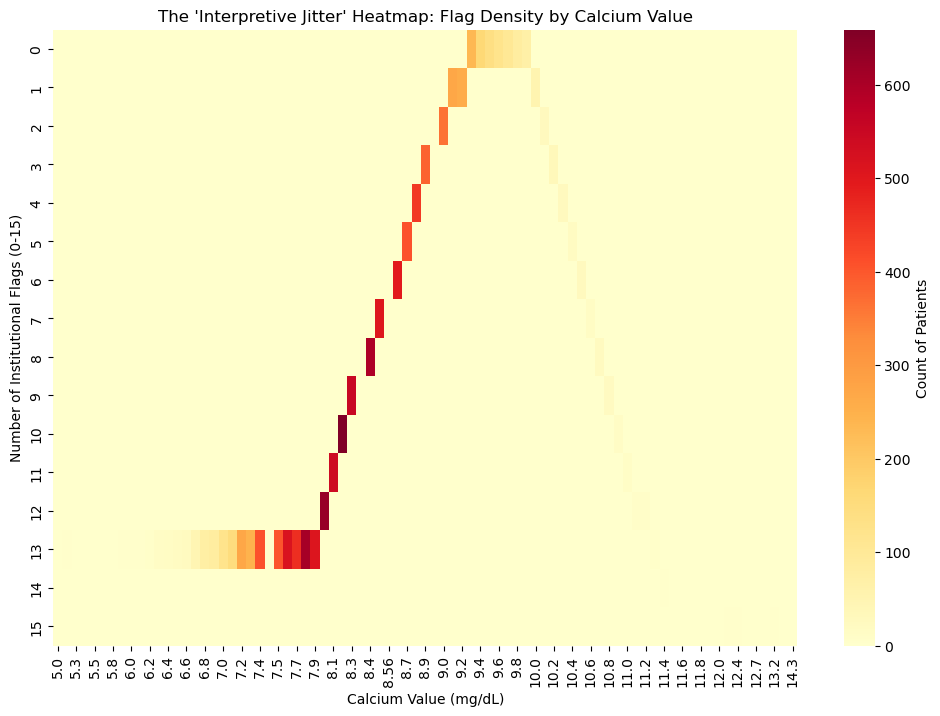

In [5]:
# 1. Extract all unique Lower and Upper limits from your network
low_limits = df['LL'].unique()
high_limits = df['UL'].unique()

# 2. Function to count how many sites would flag a specific value
def get_flag_counts(val):
    low_flags = sum(1 for ll in low_limits if val < ll)
    high_flags = sum(1 for ul in high_limits if val > ul)
    return low_flags + high_flags

# 3. Apply to your dataset
df['Total_Flags'] = df['VALUE'].apply(get_flag_counts)

# 4. Generate the Heatmap Data
# We want to see how many results fall into each "Flag Bucket" (0 to 15)
heatmap_data = df.groupby(['VALUE', 'Total_Flags']).size().unstack(fill_value=0)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data.T, cmap="YlOrRd", cbar_kws={'label': 'Count of Patients'})
plt.title("The 'Interpretive Jitter' Heatmap: Flag Density by Calcium Value")
plt.xlabel("Calcium Value (mg/dL)")
plt.ylabel("Number of Institutional Flags (0-15)")

Text(170.72222222222223, 0.5, 'Hospital Site Code')

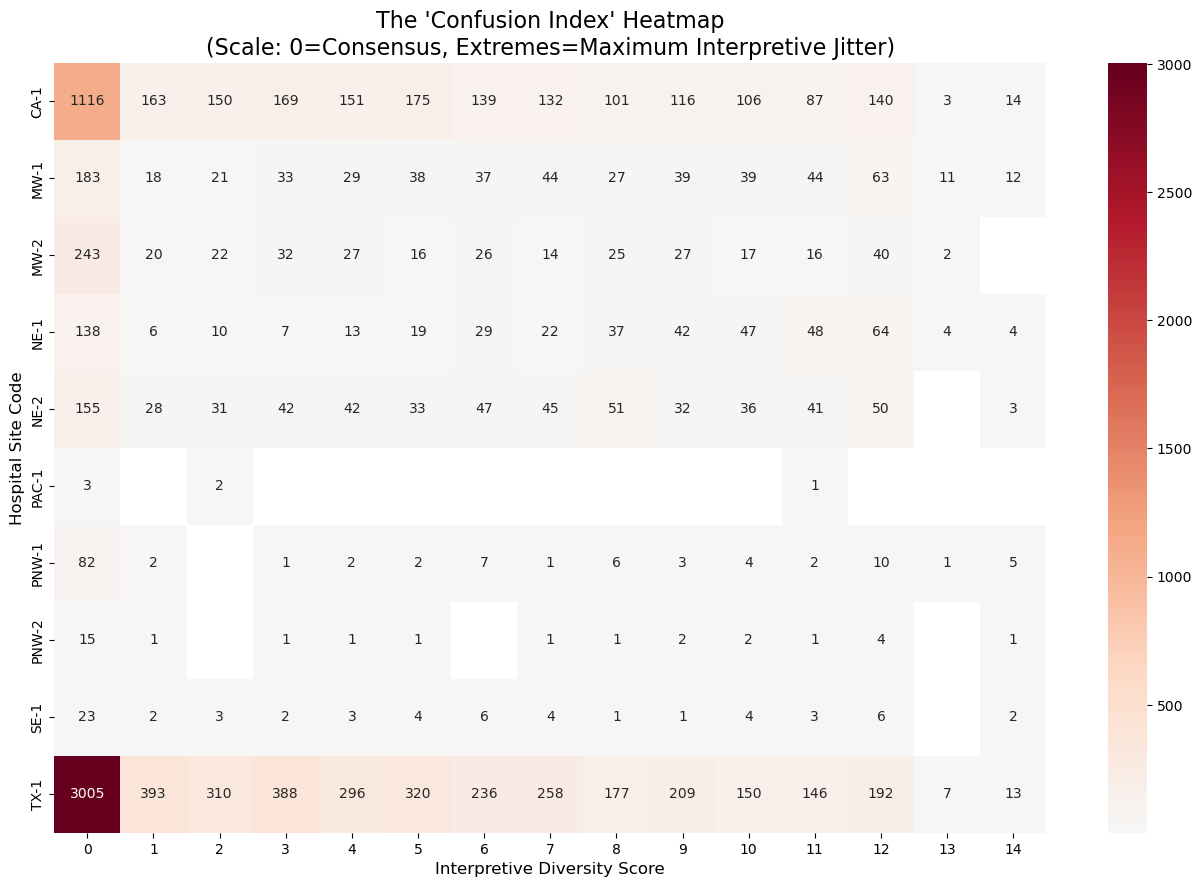

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify your 'Jury' thresholds
low_thresholds = df['LL'].unique()   # Should be 13
high_thresholds = df['UL'].unique()  # Should be 15

def calculate_idi(val):
    # Count how many sites flag this specific value
    i_low = sum(1 for ll in low_thresholds if val < ll)
    i_high = sum(1 for ul in high_thresholds if val > ul)
    
    # Logic: 0 is good (Consensus). High numbers are bad (Diversity/Chaos).
    # Universal Normal: i_low=0, i_high=0 -> Index 0
    if i_low == 0 and i_high == 0:
        return 0
    # Consensus Low: i_low=13 -> Index 0
    # Discordant Low: i_low=1 -> Index 12 (Maximum Chaos)
    if i_low > 0:
        return -(13 - i_low) # Negative indicates Low-side confusion
    # Consensus High: i_high=15 -> Index 0
    # Discordant High: i_high=1 -> Index 14 (Maximum Chaos)
    if i_high > 0:
        return (15 - i_high) # Positive indicates High-side confusion
    
    return 0

# 2. Apply the 'Confusion Index'
df['IDI'] = df['VALUE'].apply(calculate_idi).abs()

# 3. Pivot for the Heatmap
# We group by Site and the Index to see who is contributing to the 'Chaos'
pivot_idi = df.groupby(['FAC_CODE', 'IDI']).size().unstack(fill_value=0)

# 4. Plot with Annotations
plt.figure(figsize=(16, 10))
sns.heatmap(pivot_idi, 
            cmap="RdBu_r", # Diverging: Blue=Low Chaos, Red=High Chaos
            center=0,      # 0 is the 'Consensus' anchor
            annot=True,    # Print the counts in the facets
            fmt="d", 
            mask=(pivot_idi == 0))

plt.title("The 'Confusion Index' Heatmap\n(Scale: 0=Consensus, Extremes=Maximum Interpretive Jitter)", fontsize=16)
plt.xlabel("Interpretive Diversity Score", fontsize=12)
plt.ylabel("Hospital Site Code", fontsize=12)

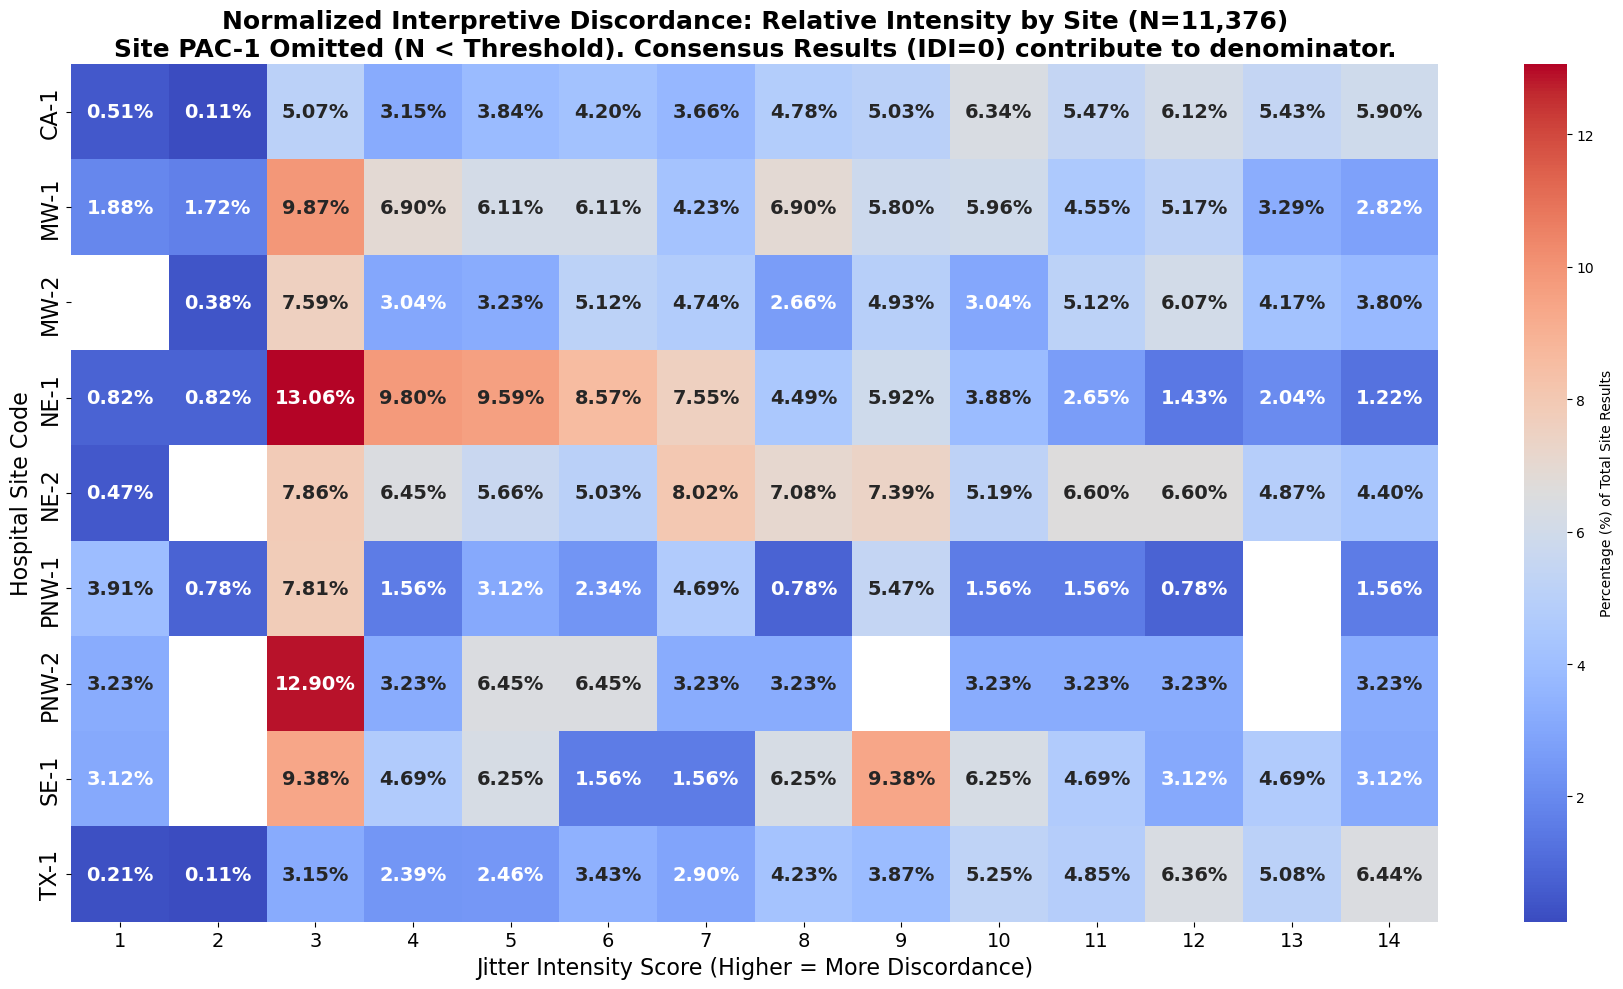

In [59]:
# 1. Calculate Site Totals & Remove PAC-1 (Insufficient N)
site_totals = pivot_idi.sum(axis=1)
pivot_idi = pivot_idi.drop(index='PAC-1', errors='ignore')
site_totals = site_totals.drop(index='PAC-1', errors='ignore')

# 2. Filter the pivot table to OMIT the '0' column (Consensus)
pivot_idi_filtered = pivot_idi.drop(columns=[0], errors='ignore')

# 3. Transform to Percentages
pivot_percent = pivot_idi_filtered.div(site_totals, axis=0) * 100

# 4. Reverse the Scale (Jitter Intensity: 15 - IDI)
pivot_percent.columns = [15 - col for col in pivot_percent.columns]
pivot_percent = pivot_percent.reindex(sorted(pivot_percent.columns), axis=1)

# 5. Create Custom Annotation Labels (2 Decimals + % Sign)
# Using applymap to format strings; empty strings for 0s to keep the plot clean
annot_labels = pivot_percent.applymap(lambda v: f"{v:.2f}%" if v > 0 else "")

# 6. Plotting the Refined Heatmap
plt.figure(figsize=(18, 10))

sns.heatmap(pivot_percent, 
            cmap="coolwarm", 
            annot=annot_labels,  # Custom string matrix
            fmt="",             # Set to empty since strings are pre-formatted
            mask=(pivot_percent == 0),
            annot_kws={"size": 14, "weight": "bold"},
            cbar_kws={'label': 'Percentage (%) of Total Site Results'})

# 7. Titles and Labels with Updated N-count
plt.title(f"Normalized Interpretive Discordance: Relative Intensity by Site (N={int(site_totals.sum()):,})\n"
          f"Site PAC-1 Omitted (N < Threshold). Consensus Results (IDI=0) contribute to denominator.", 
          fontsize=18, fontweight='bold')

plt.xlabel("Jitter Intensity Score (Higher = More Discordance)", fontsize=16)
plt.ylabel("Hospital Site Code", fontsize=16)

# Enforce the font size for axis ticks (from our previous conversation)
plt.tick_params(axis='y', labelsize=16)
plt.tick_params(axis='x', labelsize=14)

plt.tight_layout()
plt.show()

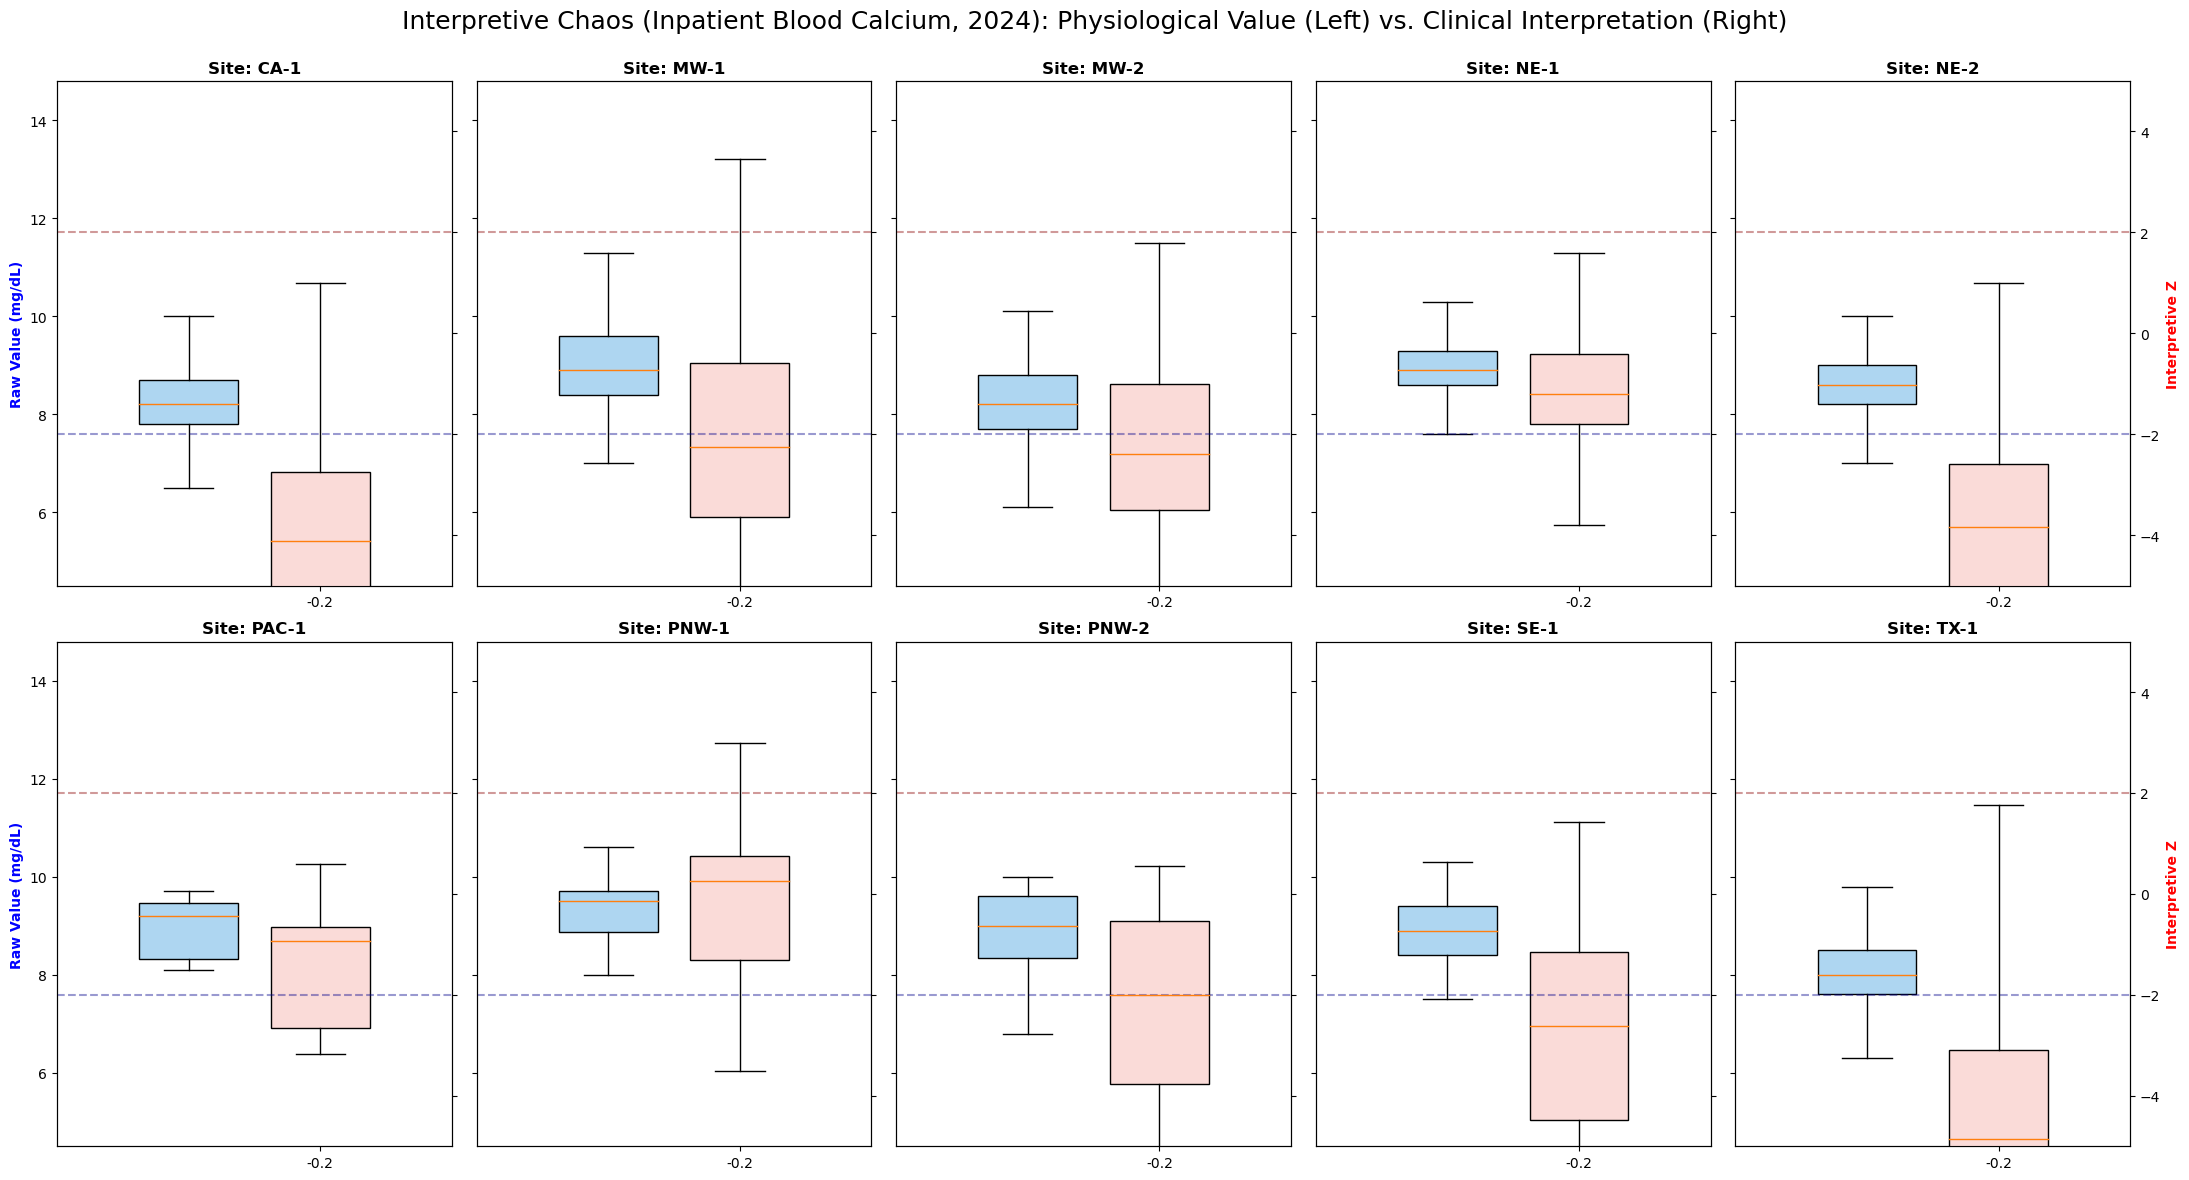

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-calculate parameters (keeping the Z-Score logic intact)
df['Midpoint'] = (df['LL'] + df['UL']) / 2
df['Assumed_SD'] = (df['UL'] - df['LL']) / 4
df['Z_Score'] = (df['VALUE'] - df['Midpoint']) / df['Assumed_SD']

# 2. Setup the Fixed Scale Grid
sites = df['FAC_CODE'].unique()
fig, axes = plt.subplots(2, 5, figsize=(22, 12))
axes_flat = axes.flatten()

y_min_raw, y_max_raw = df['VALUE'].min() - 0.5, df['VALUE'].max() + 0.5
z_min, z_max = -5, 5

for i, site in enumerate(sites):
    ax1 = axes_flat[i]
    site_data = df[df['FAC_CODE'] == site]
    
    # LEFT BOX (Blue: Raw Value) - Offset to the left
    # We pass only the y-data to avoid 'positions' conflict
    ax1.boxplot(site_data['VALUE'],showfliers = False, positions=[-0.2], widths=0.3, 
                patch_artist=True, boxprops=dict(facecolor='#AED6F1'))
    
    ax1.set_title(f"Site: {site}", fontweight='bold')
    ax1.set_ylim(y_min_raw, y_max_raw)
    ax1.set_xlim(-0.6, 0.6)
    ax1.set_xticks([]) 
    
    # RIGHT BOX (Red: Interpretive Z) - Offset to the right on Twin Axis
    ax2 = ax1.twinx()
    ax2.boxplot(site_data['Z_Score'], positions=[0.2], widths=0.3, 
                patch_artist=True,showfliers = False, boxprops=dict(facecolor='#FADBD8'))
    
    ax2.set_ylim(z_min, z_max)
    # Add the Flag Reference Lines
    ax2.axhline(-2, color='darkblue', linestyle='--', alpha=0.4)
    ax2.axhline(2, color='darkred', linestyle='--', alpha=0.4)
    
    # Axis formatting for scannability
    if i % 5 == 0: 
        ax1.set_ylabel('Raw Value (mg/dL)', color='blue', fontweight='bold')
    else: 
        ax1.set_yticklabels([])
    
    if (i + 1) % 5 == 0: 
        ax2.set_ylabel('Interpretive Z', color='red', fontweight='bold')
    else: 
        ax2.set_yticklabels([])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("Interpretive Chaos (Inpatient Blood Calcium, 2024): Physiological Value (Left) vs. Clinical Interpretation (Right)", fontsize=18)
plt.show()

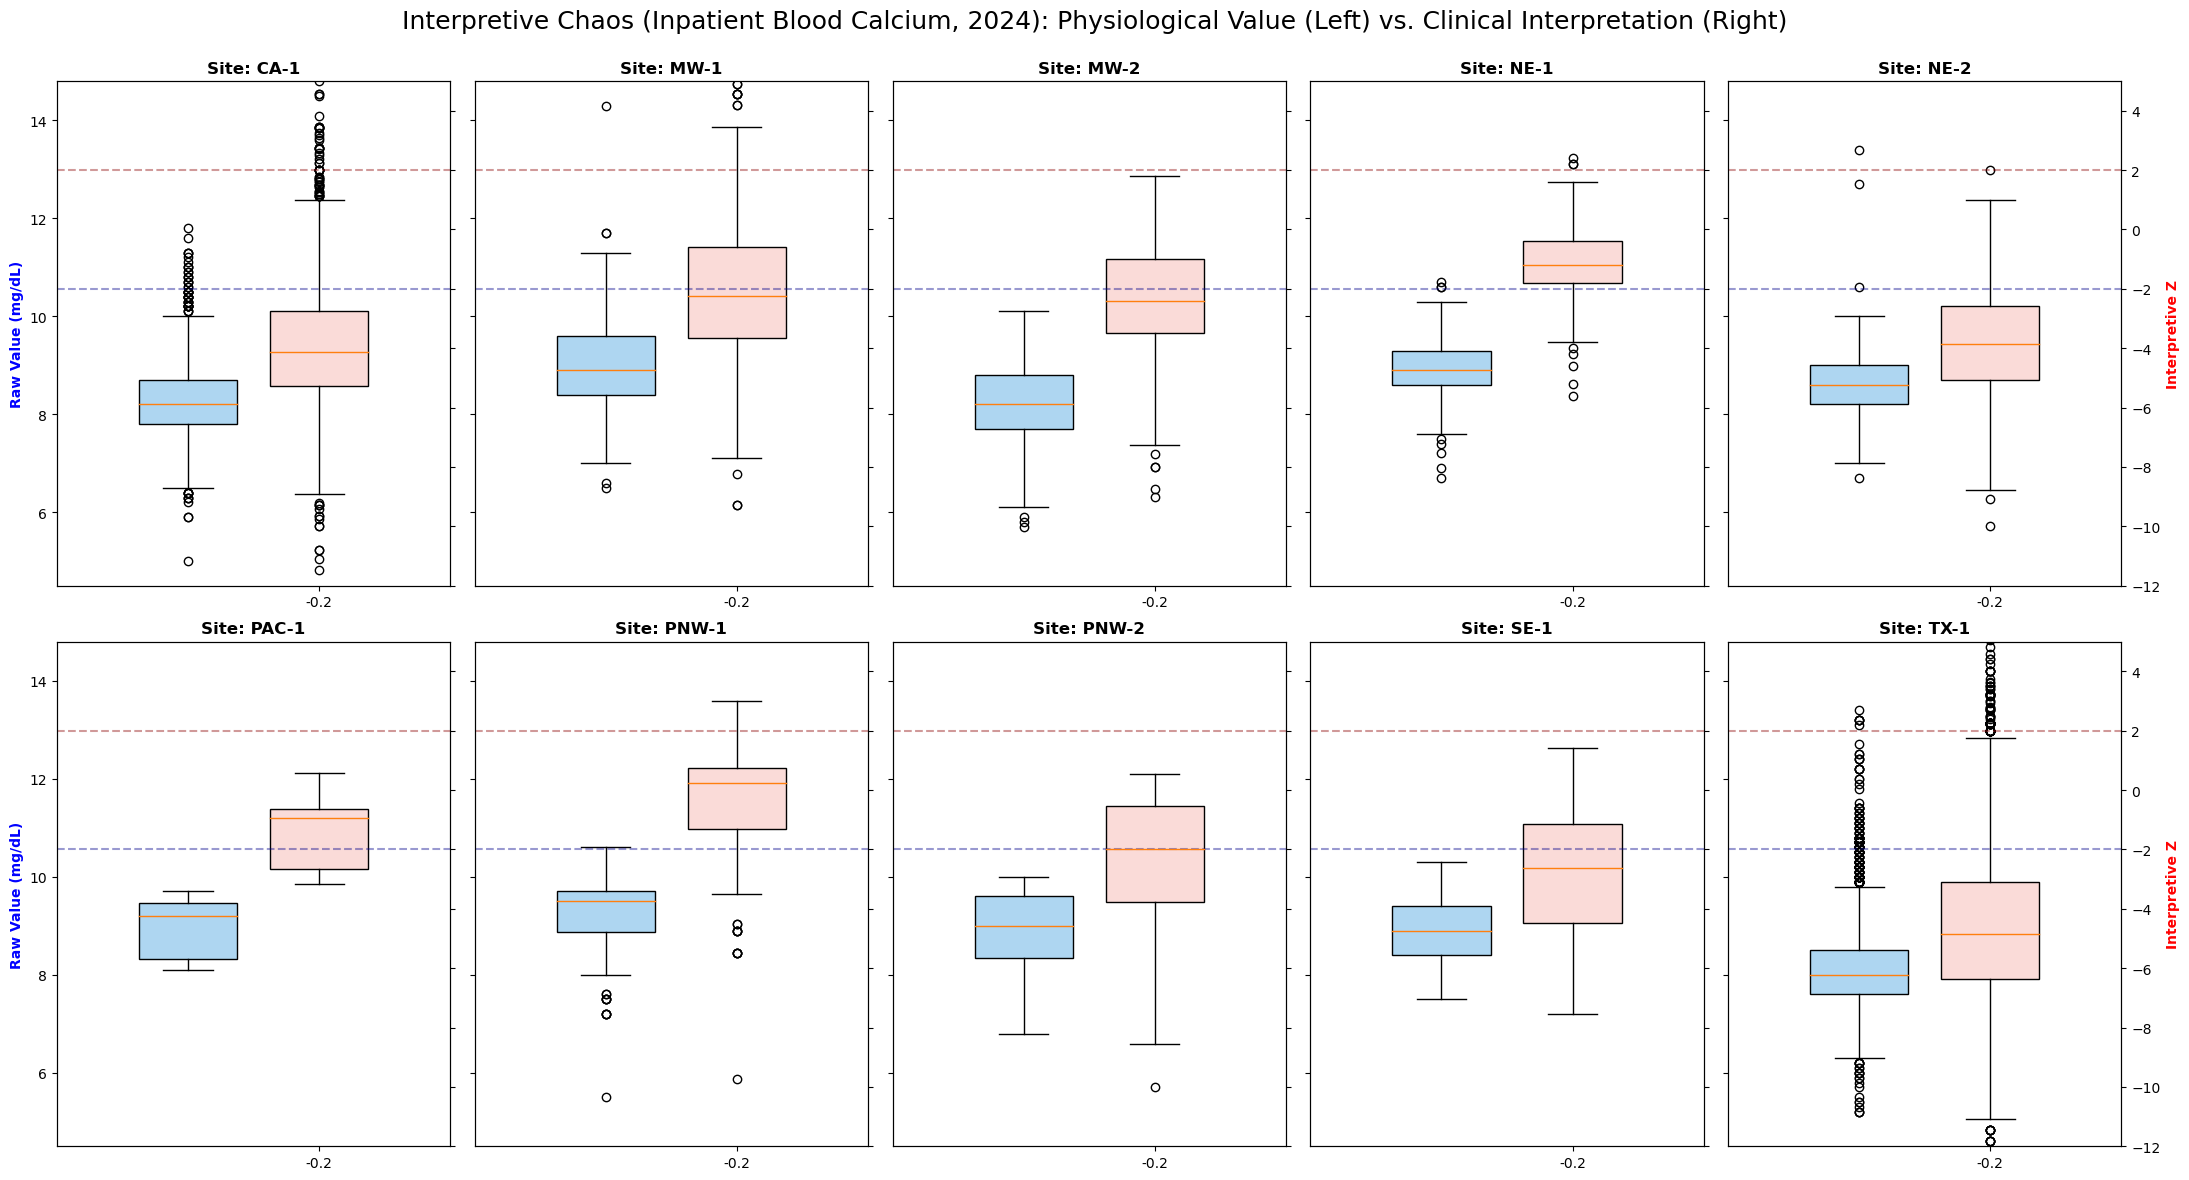

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-calculate parameters (keeping the Z-Score logic intact)
df['Midpoint'] = (df['LL'] + df['UL']) / 2
df['Assumed_SD'] = (df['UL'] - df['LL']) / 4
df['Z_Score'] = (df['VALUE'] - df['Midpoint']) / df['Assumed_SD']

# 2. Setup the Fixed Scale Grid
sites = df['FAC_CODE'].unique()
fig, axes = plt.subplots(2, 5, figsize=(22, 12))
axes_flat = axes.flatten()

y_min_raw, y_max_raw = df['VALUE'].min() - 0.5, df['VALUE'].max() + 0.5
z_min, z_max = -12, 5

for i, site in enumerate(sites):
    ax1 = axes_flat[i]
    site_data = df[df['FAC_CODE'] == site]
    
    # LEFT BOX (Blue: Raw Value) - Offset to the left
    # We pass only the y-data to avoid 'positions' conflict
    ax1.boxplot(site_data['VALUE'],showfliers = True, positions=[-0.2], widths=0.3, 
                patch_artist=True, boxprops=dict(facecolor='#AED6F1'))
    
    ax1.set_title(f"Site: {site}", fontweight='bold')
    ax1.set_ylim(y_min_raw, y_max_raw)
    ax1.set_xlim(-0.6, 0.6)
    ax1.set_xticks([]) 
    
    # RIGHT BOX (Red: Interpretive Z) - Offset to the right on Twin Axis
    ax2 = ax1.twinx()
    ax2.boxplot(site_data['Z_Score'], positions=[0.2], widths=0.3, 
                patch_artist=True,showfliers = True, boxprops=dict(facecolor='#FADBD8'))
    
    ax2.set_ylim(z_min, z_max)
    # Add the Flag Reference Lines
    ax2.axhline(-2, color='darkblue', linestyle='--', alpha=0.4)
    ax2.axhline(2, color='darkred', linestyle='--', alpha=0.4)
    
    # Axis formatting for scannability
    if i % 5 == 0: 
        ax1.set_ylabel('Raw Value (mg/dL)', color='blue', fontweight='bold')
    else: 
        ax1.set_yticklabels([])
    
    if (i + 1) % 5 == 0: 
        ax2.set_ylabel('Interpretive Z', color='red', fontweight='bold')
    else: 
        ax2.set_yticklabels([])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("Interpretive Chaos (Inpatient Blood Calcium, 2024): Physiological Value (Left) vs. Clinical Interpretation (Right)", fontsize=18)
plt.show()

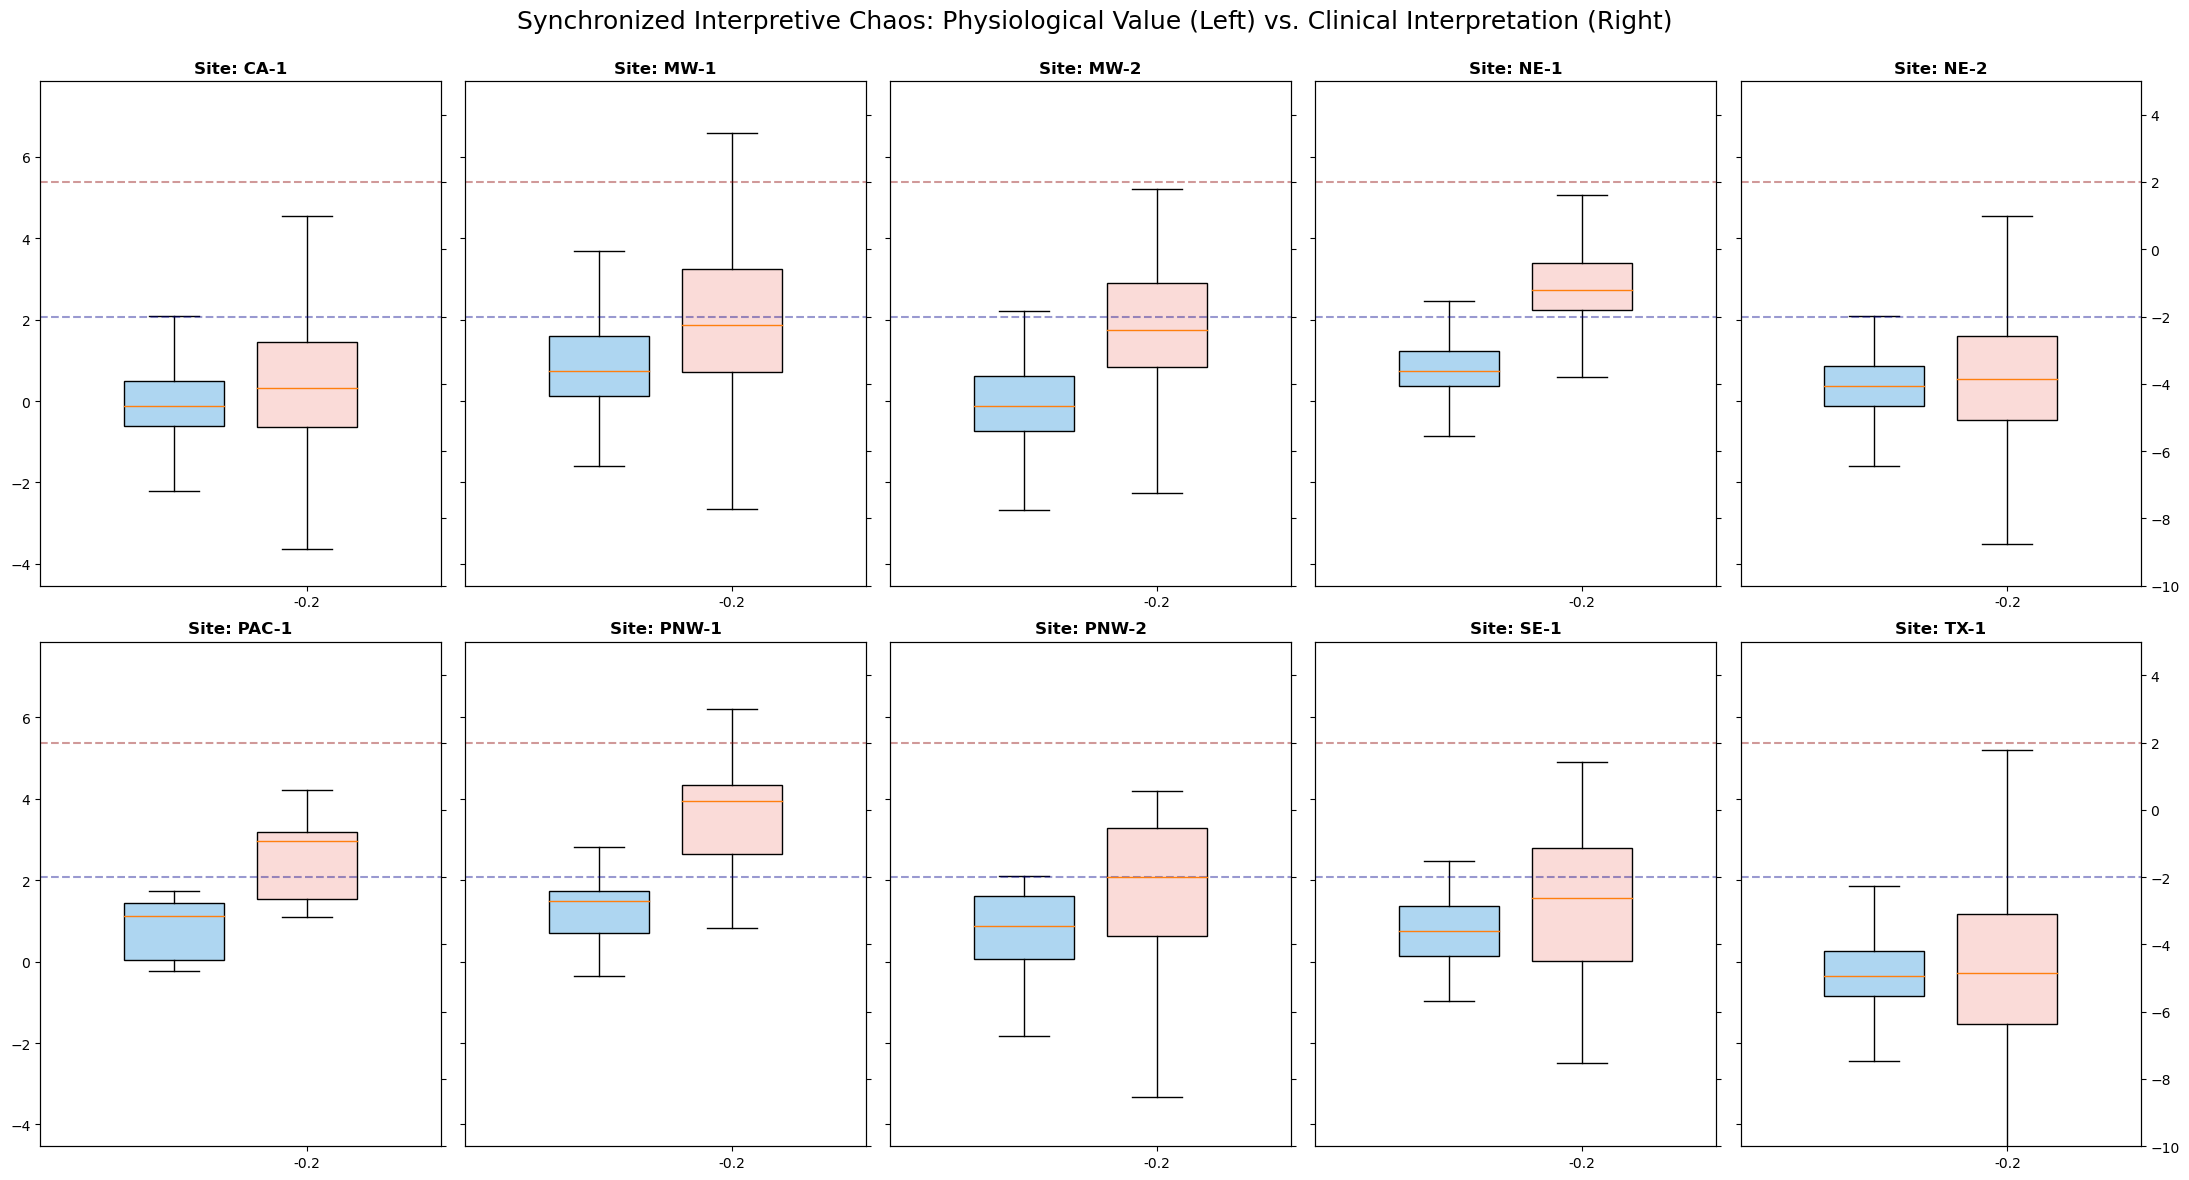

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the Fixed Scale Grid with sharey=True for primary axes
sites = df['FAC_CODE'].unique()
# sharey=True links all left-hand y-axes (ax1) together
fig, axes = plt.subplots(2, 5, figsize=(22, 12), sharey=True)
axes_flat = axes.flatten()

# Calculate global limits for Z_pop to ensure they fit the synced scale
z_pop_min, z_pop_max = df['Z_pop'].min() - 0.5, df['Z_pop'].max() + 0.5
z_min, z_max = -10, 5 # Fixed Interpretive scale

for i, site in enumerate(sites):
    ax1 = axes_flat[i]
    site_data = df[df['FAC_CODE'] == site]
    
    # LEFT BOX (Blue: Physiological Z_pop)
    ax1.boxplot(site_data['Z_pop'], showfliers=False, positions=[-0.2], widths=0.3, 
                patch_artist=True, boxprops=dict(facecolor='#AED6F1'))
    
    ax1.set_title(f"Site: {site}", fontweight='bold')
    ax1.set_xlim(-0.6, 0.6)
    ax1.set_xticks([]) 
    
    # We only need to set the limit once because sharey=True is active
    if i == 0:
        ax1.set_ylim(z_pop_min, z_pop_max)
    
    # RIGHT BOX (Red: Interpretive Z)
    ax2 = ax1.twinx()
    ax2.boxplot(site_data['Z_Score'], positions=[0.2], widths=0.3, 
                patch_artist=True, showfliers=False, boxprops=dict(facecolor='#FADBD8'))
    
    # Manually sync ax2 because twinx axes cannot be automatically shared
    ax2.set_ylim(z_min, z_max)
    
    # Add Flag Reference Lines
    ax2.axhline(-2, color='darkblue', linestyle='--', alpha=0.4)
    ax2.axhline(2, color='darkred', linestyle='--', alpha=0.4)
    
    # Clean up: only show right y-labels on the end of the rows
    if (i + 1) % 5 != 0:
        ax2.set_yticklabels([])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("Synchronized Interpretive Chaos: Physiological Value (Left) vs. Clinical Interpretation (Right)", fontsize=18)
plt.show()

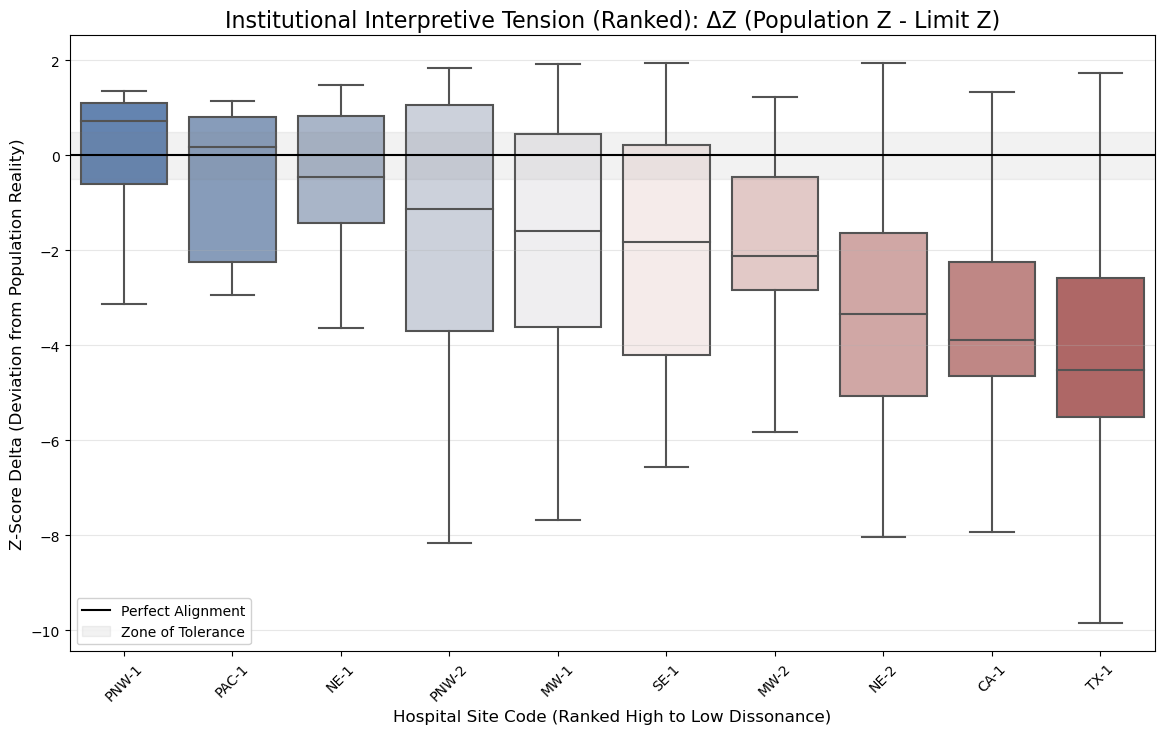

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Population and Limit Z-scores (as before)
pop_mean = df['VALUE'].mean()
pop_std = df['VALUE'].std()
df['Z_pop'] = (df['VALUE'] - pop_mean) / pop_std

df['Midpoint'] = (df['LL'] + df['UL']) / 2
df['Assumed_SD'] = (df['UL'] - df['LL']) / 4
df['Z_lim'] = (df['VALUE'] - df['Midpoint']) / df['Assumed_SD']

# 2. Calculate the Intensity Delta
df['Z_Delta'] = df['Z_pop'].abs() - df['Z_lim'].abs()

# 3. Create the SORTED order based on the median Z_Delta
# This ensures the sites are ranked from highest dissonance to lowest
site_order = df.groupby('FAC_CODE')['Z_Delta'].median().sort_values(ascending=False).index

# 4. Boxplot with explicit 'order' parameter
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, 
            x='FAC_CODE', 
            y='Z_Delta', 
            order=site_order,  # The key change
            palette='vlag', 
            showfliers=False, 
            notch=False)

# Reference line at 0 (Perfect Alignment)
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Perfect Alignment')
plt.fill_between([-0.5, len(site_order)-0.5], -0.5, 0.5, color='gray', alpha=0.1, label='Zone of Tolerance')

plt.title("Institutional Interpretive Tension (Ranked): ΔZ (Population Z - Limit Z)", fontsize=16)
plt.ylabel("Z-Score Delta (Deviation from Population Reality)", fontsize=12)
plt.xlabel("Hospital Site Code (Ranked High to Low Dissonance)", fontsize=12)
# Anchor the legend to the bottom left
plt.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

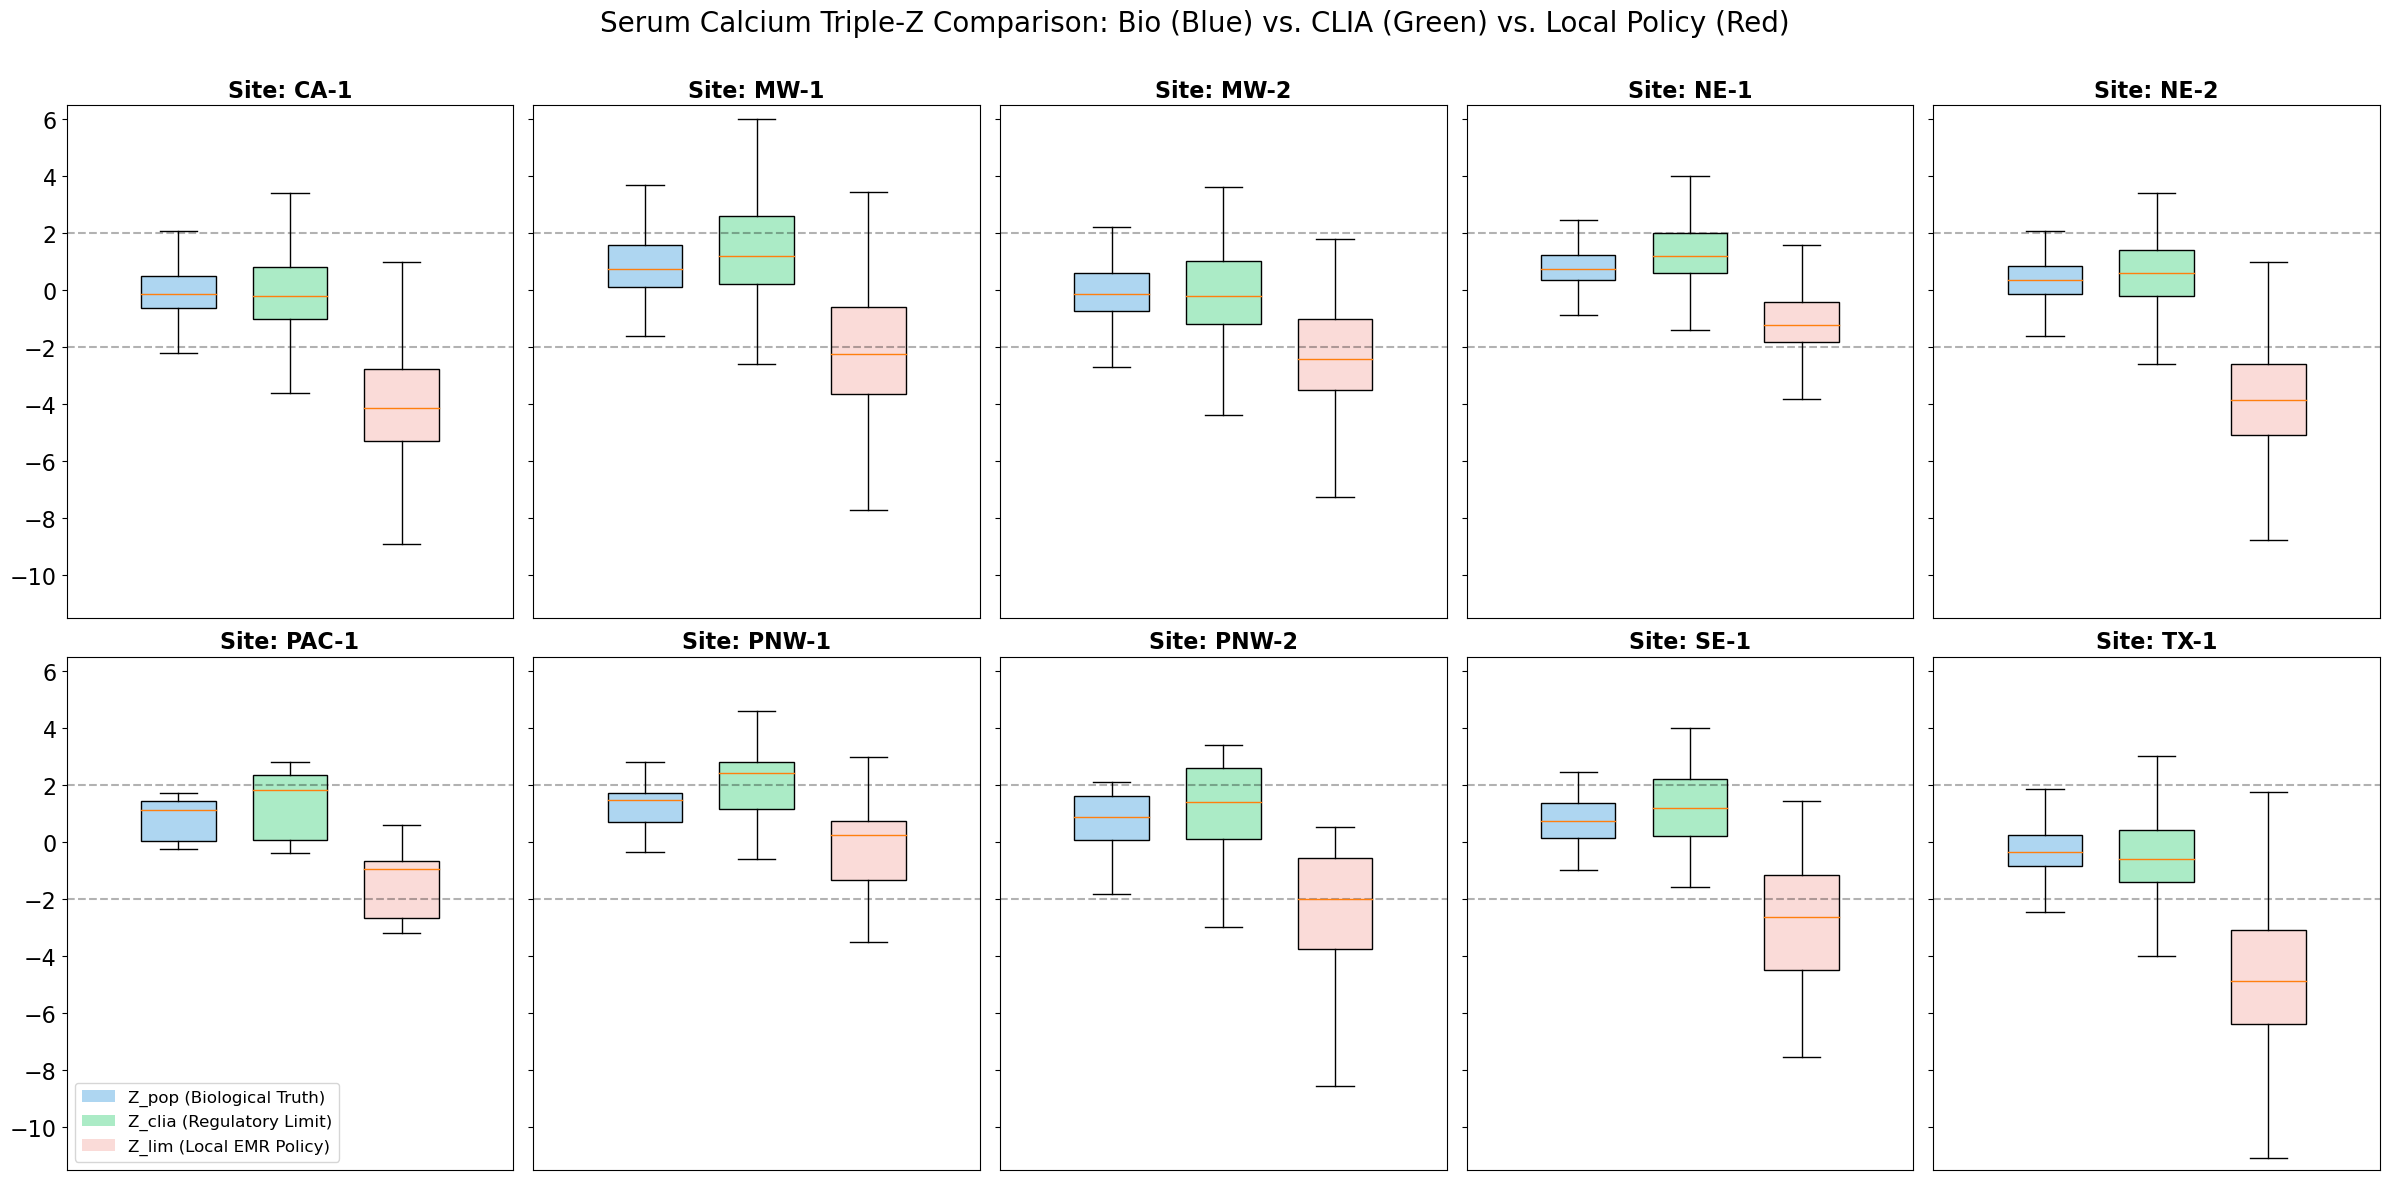

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Setup Data and Calculations
clia_sd_proxy = 1.0 / 2  # 1.0 mg/dL TEa / 2 for 2SD proxy
pop_mean, pop_std = df['VALUE'].mean(), df['VALUE'].std()

df['Z_pop'] = (df['VALUE'] - pop_mean) / pop_std
df['Z_lim'] = (df['VALUE'] - ((df['LL'] + df['UL']) / 2)) / ((df['UL'] - df['LL']) / 4)
df['Z_clia'] = (df['VALUE'] - pop_mean) / clia_sd_proxy

# 2. Setup Figure
sites = df['FAC_CODE'].unique()
fig, axes = plt.subplots(2, 5, figsize=(24, 12), sharey=True)
axes_flat = axes.flatten()
z_min, z_max = -11.5, 6.5

# 3. Define Legend Elements once
legend_elements = [
    Patch(facecolor='#AED6F1', label='Z_pop (Biological Truth)'),
    Patch(facecolor='#ABEBC6', label='Z_clia (Regulatory Limit)'),
    Patch(facecolor='#FADBD8', label='Z_lim (Local EMR Policy)')
]

for i, site in enumerate(sites):
    ax = axes_flat[i]
    site_data = df[df['FAC_CODE'] == site]
    
    # Plot side-by-side boxes
    ax.boxplot([site_data['Z_pop'], site_data['Z_clia'], site_data['Z_lim']], 
               positions=[-0.3, 0, 0.3], widths=0.2, 
               patch_artist=True, showfliers=False, manage_ticks=False)
    
    # Assign Colors
    colors = ['#AED6F1', '#ABEBC6', '#FADBD8']
    for patch, color in zip(ax.patches, colors):
        patch.set_facecolor(color)
        
    # Formatting
    ax.set_title(f"Site: {site}", fontweight='bold', fontsize = 16)
    ax.set_ylim(z_min, z_max)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_xlim(-0.6, 0.6)
    ax.set_xticks([])
    ax.axhline(-2, color='black', linestyle='--', alpha=0.3)
    ax.axhline(2, color='black', linestyle='--', alpha=0.3)

    # TARGETED LEGEND: Leftmost plot of the bottom row (Index 5 in 2x5 grid)
    if i == 5:
        ax.legend(handles=legend_elements, loc='lower left', 
                  fontsize='large', frameon=True, facecolor='white', framealpha=0.8)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle("Serum Calcium Triple-Z Comparison: Bio (Blue) vs. CLIA (Green) vs. Local Policy (Red)", fontsize=20)
plt.show()